In [ ]:
#Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
#Load the Iris Dataset

iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (150, 4)
Target Shape: (150,)


In [ ]:
#Display Dataset

print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [ ]:
#Normalize the Dataset

scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
#Create Two Train-Test Splits(Scenario 1 (70%-30%))

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
#Scenario 2 (90%-10%)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

In [ ]:
#Create MLP Models(MLP Model 1)

mlp1 = MLPClassifier(
    hidden_layer_sizes=(100,100),
    max_iter=2000,
    learning_rate_init=0.001,
    random_state=42
)

In [ ]:
#MLP Model 2

mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=2000,
    learning_rate_init=0.001,
    random_state=42
)

In [ ]:
#Train Model 1

mlp1.fit(X_train1, y_train1)

MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000, random_state=42)

In [ ]:
#Predict Using Model 1

y_pred1 = mlp1.predict(X_test1)

In [ ]:
#Train Model 2

mlp2.fit(X_train1, y_train1)

MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)

In [ ]:
#Predict Using Model 2

y_pred2 = mlp2.predict(X_test1)

In [ ]:
#Calculate Accuracy(MLP1)

accuracy1 = accuracy_score(y_test1, y_pred1)

print("MLP1 Accuracy =", accuracy1)


MLP1 Accuracy = 1.0


In [ ]:
#Calculate Accuracy(MLP2)

accuracy2 = accuracy_score(y_test1, y_pred2)

print("MLP2 Accuracy =", accuracy2)

MLP2 Accuracy = 1.0


In [ ]:
#Calculate Precision

precision1 = precision_score(
    y_test1,
    y_pred1,
    average='weighted'
)

precision2 = precision_score(
    y_test1,
    y_pred2,
    average='weighted'
)

print(precision1)
print(precision2)

1.0
1.0


In [ ]:
#Calculate Recall

recall1 = recall_score(
    y_test1,
    y_pred1,
    average='weighted'
)

recall2 = recall_score(
    y_test1,
    y_pred2,
    average='weighted'
)

print(recall1)
print(recall2)

1.0
1.0


In [ ]:
#Calculate F1 Score

f1_1 = f1_score(
    y_test1,
    y_pred1,
    average='weighted'
)

f1_2 = f1_score(
    y_test1,
    y_pred2,
    average='weighted'
)

print(f1_1)
print(f1_2)

1.0
1.0


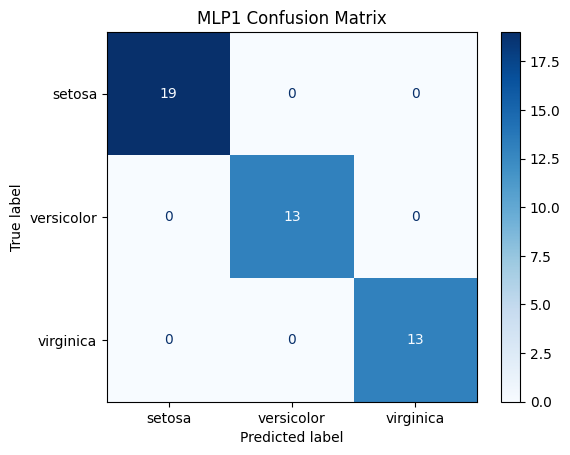

In [ ]:
#Display Confusion Matrix (MLP1)

cm1 = confusion_matrix(
    y_test1,
    y_pred1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=iris.target_names
)

disp.plot(cmap='Blues')

plt.title("MLP1 Confusion Matrix")

plt.show()

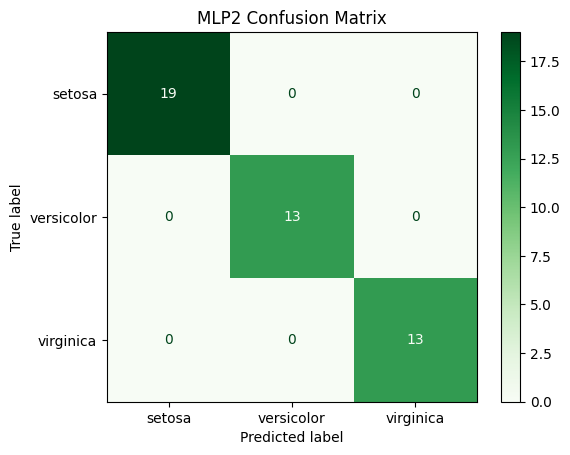

In [ ]:
#Display Confusion Matrix (MLP2)

cm2 = confusion_matrix(
    y_test1,
    y_pred2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=iris.target_names
)

disp.plot(cmap='Greens')

plt.title("MLP2 Confusion Matrix")

plt.show()

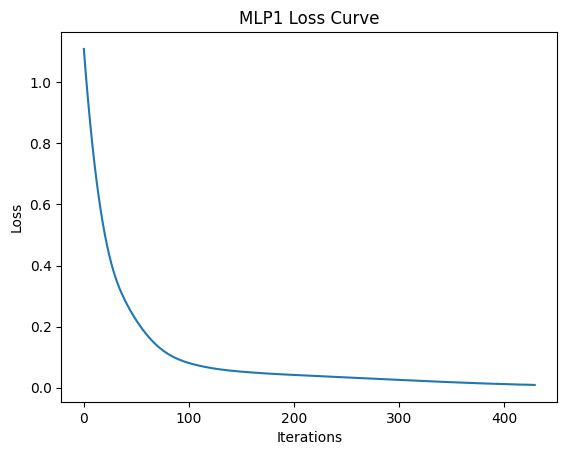

In [ ]:
#Plot Loss Curve (MLP1)

plt.plot(mlp1.loss_curve_)

plt.title("MLP1 Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.show()

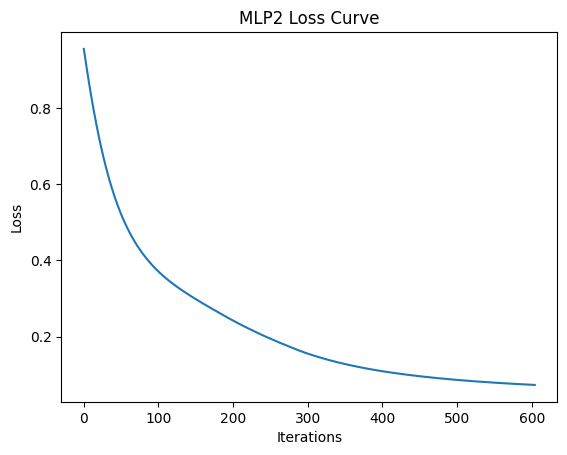

In [ ]:
#Plot Loss Curve (MLP2)

plt.plot(mlp2.loss_curve_)

plt.title("MLP2 Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.show()

In [ ]:
#Perform 10-Fold Cross Validation(MLP1)

cv1 = cross_val_score(
    mlp1,
    X_train1,
    y_train1,
    cv=10,
    scoring='f1_weighted'
)

print("MLP1 Average F1 Score =", np.mean(cv1))

MLP1 Average F1 Score = 0.9424314574314575


In [ ]:
#Perform 10-Fold Cross Validation(MLP2)

cv2 = cross_val_score(
    mlp2,
    X_train1,
    y_train1,
    cv=10,
    scoring='f1_weighted'
)

print("MLP2 Average F1 Score =", np.mean(cv2))

MLP2 Average F1 Score = 0.9321457431457432


In [ ]:
#Display Final Results

print("MLP1")
print("Accuracy :", accuracy1)
print("Precision:", precision1)
print("Recall   :", recall1)
print("F1 Score :", f1_1)

print()

print("MLP2")
print("Accuracy :", accuracy2)
print("Precision:", precision2)
print("Recall   :", recall2)
print("F1 Score :", f1_2)

MLP1
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

MLP2
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
